In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
import glob
import os

In [ ]:


# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
path_ensemble="../../ensemble_reduced/*"
path_output="../output"
sim_paths = sorted(glob.glob(path_ensemble))
file_name = "yelmo2D_reduced.nc"
ts = xr.open_dataset("../output/HTM_ens.nc")
scores = xr.open_dataset("../scoring/scores/scores_final.nc")

In [23]:
n=0
sim0=xr.open_dataset("../../ensemble_reduced/2572/"+"yelmo2D_reduced.nc")
# Kangerlussuaq Fjord
lat = 67.0050
lon = -50.6931
dist = np.sqrt((sim0.lat2D - lat)**2 + (sim0.lon2D - lon)**2)
iy, ix = np.unravel_index(dist.argmin(), dist.shape)
xc_k = sim0.isel(yc=iy, xc=ix).xc.values
yc_k = sim0.isel(yc=iy, xc=ix).yc.values


# Jakobshavn Fjord
lat = 69.1667
lon = -49.8333
dist = np.sqrt((sim0.lat2D - lat)**2 + (sim0.lon2D - lon)**2)
iy, ix = np.unravel_index(dist.argmin(), dist.shape)
xc_j = sim0.isel(yc=iy, xc=ix).xc.values
yc_j = sim0.isel(yc=iy, xc=ix).yc.values

# 79º north glacier
lat = 79.0000
lon = -25.0000
dist = np.sqrt((sim0.lat2D - lat)**2 + (sim0.lon2D - lon)**2)
iy, ix = np.unravel_index(dist.argmin(), dist.shape)
xc_n = sim0.isel(yc=iy, xc=ix).xc.values
yc_n = sim0.isel(yc=iy, xc=ix).yc.values
n_points = int(480*2/8)
xc_line = np.linspace(int(xc_n)-480, int(xc_n)+480, n_points)
yc_line = 1.22 * xc_line - 1610

In [ ]:

def get_margin_2D_formula(sim_t, xc_line, yc_line, threshold=10):
    x_points = xr.DataArray(xc_line, dims="index")
    y_points = xr.DataArray(yc_line, dims="index")
    zi = sim_t.H_ice.interp(xc=x_points, yc=y_points, method="linear")
    mask = np.where(zi < threshold,1,0)
    indices_sin_hielo = np.where(mask == 1)[0]
    if indices_sin_hielo.size > 0:
        idx = indices_sin_hielo[0]  
        return xc_line[idx], yc_line[idx]
    return None, None


def calc_d_2D_transect(yelmo, t, xc_line, yc_line):
    """
    Calcula la distancia de retroceso a lo largo de una trayectoria diagonal.
    """
    # 1. Punto del margen en t=0
    s0 = yelmo.sel(time=0, method="nearest")
    x0, y0 = get_margin_2D_formula(s0, xc_line, yc_line)
    
    # 2. Punto del margen en t=t
    st = yelmo.sel(time=t, method="nearest")
    xt, yt = get_margin_2D_formula(st, xc_line, yc_line)
    
    if x0 is None or xt is None:
        return np.nan
        
    # 3. Distancia euclidiana entre los dos puntos del margen
    dist = np.sqrt((xt - x0)**2 + (yt - y0)**2)
    
    # Si xt está "detrás" de x0 en el flujo, el retroceso es positivo
    # (Esto depende de la orientación de tu xc_line)
    return dist


/tmp/ipykernel_382192/2903260046.py:31: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(ice_0.xc, ice_0.yc, ice_0, levels=[1e-9], colors='blue', linewidths=2, label='Contorno t=0')
/tmp/ipykernel_382192/2903260046.py:32: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(ice_t.xc, ice_t.yc, ice_t, levels=[1e-9], colors='red', linewidths=2, linestyles='--', label=f'Contorno t={t}')


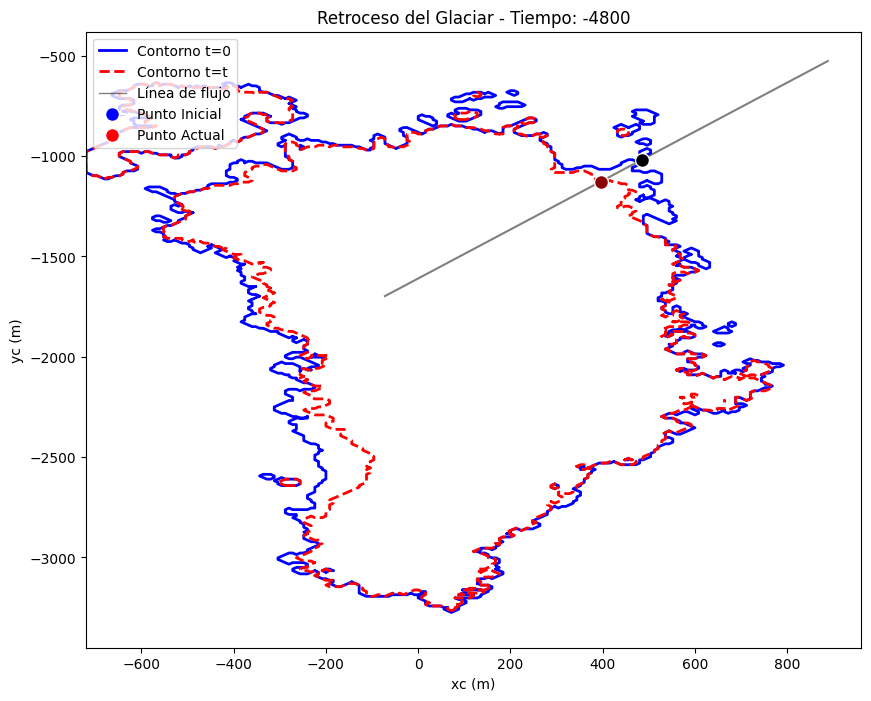

In [ ]:

def plot_margin_comparison(yelmo, t, xc_line, yc_line, x0, y0, xt, yt):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ice_0 = yelmo.H_ice.sel(time=0)
    ice_t = yelmo.H_ice.sel(time=t, method="nearest")

    ax.contour(ice_0.xc, ice_0.yc, ice_0, levels=[1e-9], colors='blue', linewidths=2, label='Contorno t=0')
    ax.contour(ice_t.xc, ice_t.yc, ice_t, levels=[1e-9], colors='red', linewidths=2, linestyles='--', label=f'Contorno t={t}')

    ax.plot(xc_line, yc_line, color='black', alpha=0.5, label='Eje del glaciar')

    # 3. Marcamos los puntos detectados
    ax.scatter(x0, y0, color='black', s=100, edgecolors='white', label='Margen Inicial (t=0)', zorder=5)
    ax.scatter(xt, yt, color='darkred', s=100, edgecolors='white', label=f'Margen Actual (t={t})', zorder=5)

    # 4. Detalles estéticos
    ax.set_title(f"Retroceso del Glaciar - Tiempo: {t}")
    ax.set_xlabel("xc (m)")
    ax.set_ylabel("yc (m)")
    
    # Creamos una leyenda personalizada
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='blue', lw=2),
                    Line2D([0], [0], color='red', lw=2, linestyle='--'),
                    Line2D([0], [0], color='black', lw=1, alpha=0.5),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10)]
    
    ax.legend(custom_lines, ['Contorno t=0', 'Contorno t=t', 'Línea de flujo', 'Punto Inicial', 'Punto Actual'])
    
    plt.show()

x0, y0 = get_margin_2D_formula(sim0.sel(time=0), xc_line, yc_line)
xt, yt = get_margin_2D_formula(sim0.sel(time=-4800), xc_line, yc_line)
plot_margin_comparison(sim0, -4800, xc_line, yc_line, x0, y0, xt, yt)

In [51]:

# ---------------------------------------------
# Calculations
# This script creates a NetCDF file with ensemble timeseries from yelmo2D files
# It includes the time and the distance to the pd margin en Kangerlussuaq y en Jakobshavn
# ---------------------------------------------

def calc_d(sim0,t,yc):

    s0 = sim0.sel(time = 0).sel(yc = yc)
    indices = np.where(np.abs(s0.H_ice) > 1e-9)[0]
    if indices.size > 0:
        x_t0 = s0.xc.values[indices[0]]

    s1 = sim0.sel(time = t, method="nearest").sel(yc = yc)
    indices = np.where(np.abs(s1.H_ice) > 1e-9)[0]
    if indices.size > 0:
        x_t1 = s1.xc.values[indices[0]]
    d = x_t1 - x_t0
    return d

d_ens_k =[]
d_ens_j =[]
d_ens_n =[]
valid_sim_indices = []   

for i, sim_path in enumerate(sim_paths):

    file_path = os.path.join(sim_path, file_name)
    n_sim = int(os.path.basename(sim_path))

    yelmo = xr.open_dataset(file_path)

    time = ts.sel(sim=n_sim).time.values
    d_k = calc_d(yelmo, time, yc_k)
    d_ens_k.append(d_k)
    d_j = calc_d(yelmo, time, yc_j)
    d_ens_j.append(d_j)
    valid_sim_indices.append(n_sim)   
    d_n = calc_d_2D_transect(yelmo, time, xc_line, yc_line)
    d_ens_n.append(d_n)

d_ens_k = np.stack(d_ens_k, axis=0)
d_ens_j = np.stack(d_ens_j, axis=0)
d_ens_n = np.stack(d_ens_n, axis=0)
valid_sim_indices = np.stack(valid_sim_indices, axis=0)

ds_ensemble = xr.Dataset(
    data_vars={
        "d_kan": (("sim"), d_ens_k),
        "d_jak": (("sim"), d_ens_j),
        "d_nor": (("sim"), d_ens_n)
    },
    coords={
        "sim": np.array(valid_sim_indices)
    }
)

ds_ensemble = ds_ensemble.sortby("sim")


In [52]:
ds_ensemble.to_netcdf(f"{path_output}/HTM_distances.nc")